# Tracking an object using the Kalman filter

*This example is adapted from the [dynamax notebook of the same name](https://probml.github.io/dynamax/notebooks/linear_gaussian_ssm/kf_tracking.html).*

Consider an object moving in $\mathbb{R}^2$.
We assume that we observe a noisy version of its location at each time step.
We want to track the object and possibly forecast its future motion.
We now show how to do this using a simple linear Gaussian SSM, combined with
the Kalman filter algorithm.

Let the hidden state represent
the position and velocity of the object,
$z_t = (u_t,\ v_t,\ \dot{u}_t,\ \dot{v}_t)$.
(We use $u$ and $v$ for the two coordinates,
to avoid confusion with the state and observation variables.)
The process evolves in continuous time, but if we discretize it with step size $\Delta$,
we can write the dynamics as the following linear system:

\begin{align*}
\underbrace{\begin{pmatrix} u_t\\ v_t \\ \dot{u}_t \\ \dot{v}_t \end{pmatrix}}_{z_t}
  =
\underbrace{
\begin{pmatrix}
1 & 0 & \Delta & 0 \\
0 & 1 & 0 & \Delta\\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{pmatrix}
}_{F}
\underbrace{\begin{pmatrix} u_{t-1} \\ v_{t-1} \\ \dot{u}_{t-1} \\ \dot{v}_{t-1} \end{pmatrix}}_{z_{t-1}}
+ q_t
\end{align*}

where $q_t \in \mathbb{R}^4$ is the process noise, which we assume is Gaussian,
so  $q_t \sim \mathcal{N}(0,Q)$.

Now suppose that at each discrete time point we
observe the location (but not the velocity).
We assume the observation is corrupted by  Gaussian noise.
Thus the observation model becomes

\begin{align*}
\underbrace{\begin{pmatrix}  y_{1,t} \\  y_{2,t} \end{pmatrix}}_{y_t}
  &=
    \underbrace{
    \begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0
    \end{pmatrix}
    }_{H}
\underbrace{\begin{pmatrix} u_t\\ v_t \\ \dot{u}_t \\ \dot{v}_t \end{pmatrix}}_{z_t}
 + r_t
\end{align*}

where $r_t \sim \mathcal{N}(0,R)$ is the observation noise.
We see that the observation matrix $H$ simply _extracts_ the
relevant parts of the state vector.

## Setup

In [1]:
import numpyro.distributions as dist
from jax import numpy as jnp
from jax import random as jr
from jax import vmap
from matplotlib import pyplot as plt
from matplotlib.patches import Ellipse, transforms

import dynestyx as dsx
from dynestyx import DynamicalModel
from dynestyx.inference.filters import Filter, KFConfig
from dynestyx.inference.integrations.utils import covariance_from_cholesky
from dynestyx.inference.smoothers import KFSmootherConfig, Smoother
from dynestyx.models import LinearGaussianObservation, LinearGaussianStateEvolution

## Create the model

In [2]:
state_dim = 4
emission_dim = 2
delta = 1.0

# Manually chosen parameters
initial_mean = jnp.array([8.0, 10.0, 1.0, 0.0])
initial_covariance = jnp.eye(state_dim) * 0.1
dynamics_weights = jnp.array(
    [[1, 0, delta, 0], [0, 1, 0, delta], [0, 0, 1, 0], [0, 0, 0, 1]]
)
dynamics_covariance = jnp.eye(state_dim) * 0.001
emission_weights = jnp.array([[1.0, 0, 0, 0], [0, 1.0, 0, 0]])
emission_covariance = jnp.eye(emission_dim)

# In dynestyx a model is a DynamicalModel built from an initial condition, a
# state evolution, and an observation model.
lgssm = DynamicalModel(
    initial_condition=dist.MultivariateNormal(initial_mean, initial_covariance),
    state_evolution=LinearGaussianStateEvolution(
        A=dynamics_weights, cov=dynamics_covariance
    ),
    observation_model=LinearGaussianObservation(
        H=emission_weights, R=emission_covariance
    ),
)

## Sample some data from the model

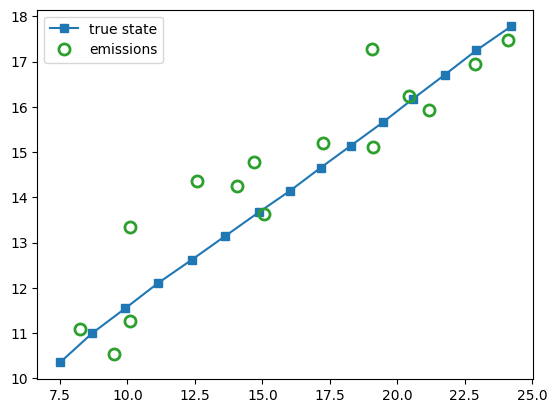

In [3]:
num_timesteps = 15
key = jr.PRNGKey(310)
obs_times = jnp.arange(float(num_timesteps))


# Pure forward simulation uses an explicit PRNG key. The result carries a
# leading n_simulations axis, which we index here for the single trajectory.
sample = dsx.simulate(lgssm, rng_key=key, predict_times=obs_times)
x = sample.states[0]
y = sample.observations[0]

# Plot Data
observation_marker_kwargs = {
    "marker": "o",
    "markerfacecolor": "none",
    "markeredgewidth": 2,
    "markersize": 8,
}
fig, ax = plt.subplots()
ax.plot(*x[:, :2].T, marker="s", color="C0", label="true state")
ax.plot(*y.T, ls="", **observation_marker_kwargs, color="tab:green", label="emissions")
ax.legend(loc="upper left")
plt.show()

In [4]:
def plot_lgssm_posterior(
    post_means, post_covs, ax=None, ellipse_kwargs=None, legend_kwargs=None, **kwargs
):
    """Plot posterior means and covariances for the first two dimensions of
     the latent state of a LGSSM.

    Args:
        post_means: array(T, D).
        post_covs: array(T, D, D).
        ax: matplotlib axis.
        ellipse_kwargs: keyword arguments passed to matplotlib.patches.Ellipse().
        **kwargs: passed to ax.plot().
    """
    ellipse_kwargs = {} if ellipse_kwargs is None else ellipse_kwargs
    legend_kwargs = {} if legend_kwargs is None else legend_kwargs
    if ax is None:
        _, ax = plt.subplots()

    # Select the first two dimensions of the latent space.
    post_means = post_means[:, :2]
    post_covs = post_covs[:, :2, :2]

    # Plot the mean trajectory
    ax.plot(post_means[:, 0], post_means[:, 1], **kwargs)
    # Plot covariance at each time point.
    plot_uncertainty_ellipses(post_means, post_covs, ax, **ellipse_kwargs)

    ax.axis("equal")

    if "label" in kwargs:
        ax.legend(**legend_kwargs)

    return ax

In [5]:
def plot_ellipse(cov, mean, ax, n_std=3.0, facecolor="none", edgecolor="k", **kwargs):
    """Plot an `n_std` covariance ellipse centred at `mean`."""
    pearson = cov[0, 1] / jnp.sqrt(cov[0, 0] * cov[1, 1])
    ellipse = Ellipse(
        (0, 0),
        width=2 * jnp.sqrt(1 + pearson),
        height=2 * jnp.sqrt(1 - pearson),
        facecolor=facecolor,
        edgecolor=edgecolor,
        **kwargs,
    )
    scale_x = jnp.sqrt(cov[0, 0]) * n_std
    scale_y = jnp.sqrt(cov[1, 1]) * n_std
    transform = (
        transforms.Affine2D().rotate_deg(45).scale(scale_x, scale_y).translate(*mean)
    )
    ellipse.set_transform(transform + ax.transData)
    return ax.add_patch(ellipse)


def plot_uncertainty_ellipses(means, covs, ax, n_std=3.0, label=None, **kwargs):
    """Add a covariance ellipse at each (mean, cov), labelling only the first."""
    for i, (cov, mean) in enumerate(zip(covs, means)):
        plot_ellipse(cov, mean, ax, n_std, label=label if i == 0 else None, **kwargs)

## Perform online filtering

We run the Kalman filter with `Filter(KFConfig(...))`. `dsx.condition` returns a result object holding the marginal log-likelihood and the filtered states; we ask the filter to record the filtered means and covariances.

In [6]:
with Filter(
    filter_config=KFConfig(
        filter_source="cuthbert",
        record_filtered_states_mean=True,
        record_filtered_states_cov=True,
    )
):
    filtered = dsx.condition("lgssm", lgssm, obs_times=obs_times, obs_values=y)

filtered_means = filtered.states.mean
filtered_covariances = covariance_from_cholesky(filtered.states.chol_cov)
print(filtered_means.shape)
print(filtered_covariances.shape)
print(filtered.marginal_loglik)

(15, 4)
(15, 4, 4)
-47.98203


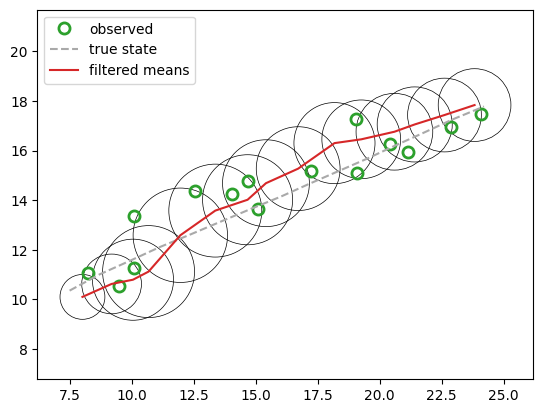

In [7]:
fig, ax = plt.subplots()
ax.plot(*y.T, ls="", **observation_marker_kwargs, color="tab:green", label="observed")
ax.plot(*x[:, :2].T, ls="--", color="darkgrey", label="true state")
plot_lgssm_posterior(
    filtered_means,
    filtered_covariances,
    ax,
    color="tab:red",
    label="filtered means",
    ellipse_kwargs={"edgecolor": "k", "linewidth": 0.5},
    legend_kwargs={"loc": "upper left"},
)
plt.show()

## Perform offline smoothing

Smoothing conditions on the whole sequence. We use `Smoother(KFSmootherConfig(...))` in place of the filter.

In [8]:
with Smoother(
    smoother_config=KFSmootherConfig(
        filter_source="cuthbert",
        record_smoothed_states_mean=True,
        record_smoothed_states_cov=True,
    )
):
    smoothed = dsx.condition("lgssm", lgssm, obs_times=obs_times, obs_values=y)

smoothed_means = smoothed.states.mean
smoothed_covariances = covariance_from_cholesky(smoothed.states.chol_cov)

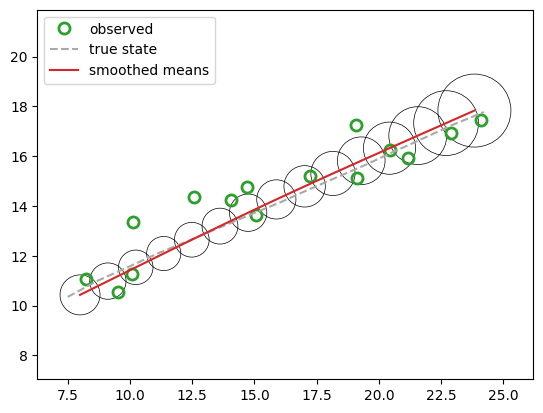

In [9]:
fig, ax = plt.subplots()
ax.plot(*y.T, ls="", **observation_marker_kwargs, color="tab:green", label="observed")
ax.plot(*x[:, :2].T, ls="--", color="darkgrey", label="true state")
plot_lgssm_posterior(
    smoothed_means,
    smoothed_covariances,
    ax,
    color="tab:red",
    label="smoothed means",
    ellipse_kwargs={"edgecolor": "k", "linewidth": 0.5},
    legend_kwargs={"loc": "upper left"},
)
plt.show()

## Tracking multiple objects in parallel

We can track several independent trajectories at once. We generate 4 sample trajectories and then `vmap` the filter and smoother over them.

In [10]:
num_samples = 4

# Draw several independent trajectories in one pure-JAX simulation call.
samples = dsx.simulate(
    lgssm,
    rng_key=jr.PRNGKey(123),
    predict_times=obs_times,
    n_simulations=num_samples,
)
xs = samples.states  # (num_samples, T, state_dim)
ys = samples.observations  # (num_samples, T, emission_dim)

In [11]:
# vmap the inference over the trajectories.
def filter_one(y_single):
    with Filter(
        filter_config=KFConfig(
            filter_source="cuthbert",
            record_filtered_states_mean=True,
            record_filtered_states_cov=True,
        )
    ):
        result = dsx.condition("lgssm", lgssm, obs_times=obs_times, obs_values=y_single)
    return result.states.mean, covariance_from_cholesky(result.states.chol_cov)


def smooth_one(y_single):
    with Smoother(
        smoother_config=KFSmootherConfig(
            filter_source="cuthbert",
            record_smoothed_states_mean=True,
            record_smoothed_states_cov=True,
        )
    ):
        result = dsx.condition("lgssm", lgssm, obs_times=obs_times, obs_values=y_single)
    return result.states.mean, covariance_from_cholesky(result.states.chol_cov)


filtered_means_all, filtered_covs_all = vmap(filter_one)(ys)
smoothed_means_all, smoothed_covs_all = vmap(smooth_one)(ys)

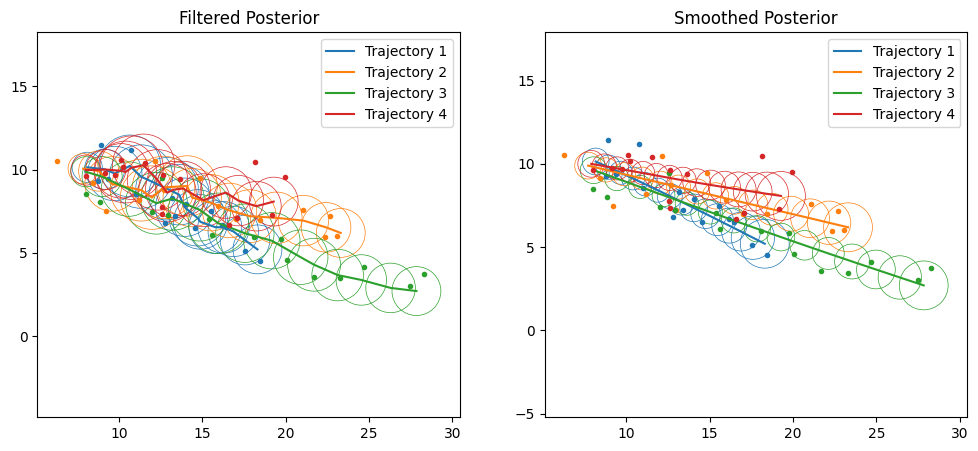

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
posteriors = [
    ("Filtered Posterior", filtered_means_all, filtered_covs_all),
    ("Smoothed Posterior", smoothed_means_all, smoothed_covs_all),
]
for ax, (title, means_all, covs_all) in zip(axes, posteriors):
    for n in range(num_samples):
        ax.plot(*ys[n, ...].T, ".", color=f"C{n}")
        plot_lgssm_posterior(
            means_all[n],
            covs_all[n],
            ax,
            color=f"C{n}",
            ellipse_kwargs={"edgecolor": f"C{n}", "linewidth": 0.5},
            label=f"Trajectory {n + 1}",
        )
    ax.set_title(title)
axes[0].legend(fontsize=10)
plt.show()